In [16]:
import attrs
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import copy
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import torchvision
import matplotlib.ticker as ticker
import sys
import os

In [ ]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Extract spatial features, reducing each 28x28 image to a 16x5x5 feature map.
        self.feature = nn.Sequential(
            # 1
            nn.Conv2d(
                in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2
            ),  # 28*28->32*32-->28*28
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 14*14
            # 2
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),  # 10*10
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 5*5
        )
        # Produce a 42-dimensional representation before mapping it to 10 class logits.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=16 * 5 * 5, out_features=60),
            nn.Tanh(),
            nn.Linear(in_features=60, out_features=42),
            nn.Tanh(),
        )
        self.Bob = nn.Sequential(
            nn.Linear(in_features=42, out_features=10),
        )

    def forward(self, x):
        z = self.classifier(self.feature(x))
        out = self.Bob(z)
        # Return both class logits and the intermediate representation for analysis.
        return out, z


model = LeNet()
model.load_state_dict(
    torch.load("../../checkpoints/mnist_example.pth", weights_only=True)
)

<All keys matched successfully>

In [18]:
train_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,)),
    ]
)
rnd_perm = np.random.permutation(np.arange(0, 60000))
full_trainset = torchvision.datasets.MNIST(
    "../../data", train=True, download=True, transform=train_transform
)
# The same one from the src/zo_dynamics/mnist_example.py
np.random.seed(12345)
train_subset = torch.utils.data.Subset(full_trainset, list(rnd_perm[:20000]))
test_subset = torch.utils.data.Subset(full_trainset, list(rnd_perm[20000:40000]))

seed_loader = torch.utils.data.DataLoader(train_subset, batch_size=2000, shuffle=False)
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=2000, shuffle=False)

In [ ]:
def calc_jacobian_z(z, model):
    # Each row contains one output's gradients with respect to all model parameters.
    params = list(model.parameters())
    num_outputs = z.shape[1]
    jacobian_rows = []

    for i in range(num_outputs):
        # Calculate the gradients for z[0, i] w.r.t. all params.
        # This returns a tuple of gradients, one for each param.
        grad_tuple = torch.autograd.grad(
            outputs=z[0, i],  # The scalar output element
            inputs=params,  # The parameters you want gradients for
            retain_graph=True,  # Must keep graph for next loop iteration
            allow_unused=True,  # Some params might not contribute to the output
        )

        # Flatten and concatenate the gradients into a single row vector
        grad_row = torch.cat([g.flatten() for g in grad_tuple if g is not None])
        jacobian_rows.append(grad_row)

    # Stack all rows to get the Jacobian
    jacobian = torch.stack(jacobian_rows)
    return jacobian

In [20]:
SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))  # Back to src
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)
from zo_llm.util.metrics import Metric

DEVICE = "cuda"
model.to(DEVICE)
model.eval()
with torch.no_grad():
    test_loss = Metric("Test loss")
    test_acc = Metric("Test acc")
    for data_iter_step, (x, y) in enumerate(test_loader):
        x, y = x.float().to(DEVICE), y.long().to(DEVICE)
        outputs, z = model(x)
        loss = nn.CrossEntropyLoss()(outputs, y)
        test_loss.update(loss.item())
        test_acc.update((outputs.argmax(dim=1) == y).sum().item())

In [ ]:
def plot_ntk(idx1, idx2, seed: int | None, num_pert: int):
    data1, label1 = train_subset[idx1]
    data2, label2 = test_subset[idx2]
    fig, ax = plt.subplots(2, 2, figsize=(6, 5))
    plt.subplots_adjust(hspace=0.4)
    ax[0][0].imshow(data1[0, :].squeeze())
    ax[0][0].set_title(f"Label={label1}")
    ax[0][1].imshow(data2[0, :].squeeze())
    ax[0][1].set_title(f"Label={label2}")
    for a in [ax[0][0], ax[0][1]]:
        a.xaxis.set_major_locator(ticker.MultipleLocator(5))
        a.yaxis.set_major_locator(ticker.MultipleLocator(5))

    pos = ax[0][0].get_position()
    ax[0][0].set_position([pos.x0 + 0.01, pos.y0, pos.width, pos.height])

    pos = ax[0][1].get_position()
    ax[0][1].set_position([pos.x0 - 0.03, pos.y0, pos.width, pos.height])

    output1, z = model(torch.unsqueeze(data1, dim=0).float().to(DEVICE))
    output2, z = model(torch.unsqueeze(data2, dim=0).float().to(DEVICE))
    # These Jacobians are for the class logits; their product gives the first-order eNTK.
    jacobian1 = calc_jacobian_z(output1, model)
    jacobian2 = calc_jacobian_z(output2, model)

    ntk_fo = (jacobian1 @ jacobian2.T).cpu()
    # Random parameter-space projections estimate the full kernel using num_pert directions.
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)
    u = torch.normal(mean=0, std=1, size=(num_pert, jacobian1.shape[1])).to(DEVICE)
    ntk_zo = (jacobian1 @ u.T @ u @ jacobian2.T).cpu() / num_pert

    vmin = min(ntk_fo.min(), ntk_zo.min())
    vmax = max(ntk_fo.max(), ntk_zo.max())

    im1 = ax[1][0].imshow(ntk_fo, vmin=vmin, vmax=vmax)
    im2 = ax[1][1].imshow(ntk_zo, vmin=vmin, vmax=vmax)
    ax[1][0].set_title(f"FO eNTK")
    ax[1][1].set_title(f"ZO eNTK, P={num_pert}")
    for a in [ax[1][0], ax[1][1]]:
        a.xaxis.set_major_locator(ticker.MultipleLocator(2))
        a.yaxis.set_major_locator(ticker.MultipleLocator(2))

    cbar = fig.colorbar(
        im1, ax=[ax[1][0], ax[1][1]], orientation="vertical", fraction=0.05, pad=0.04
    )
    cbar.set_label("NTK Value")

# Plot eNTK with different number of perturbations

In [ ]:
def plot_ntk_p(idx1, idx2, seed: int | None, pert=[1, 50, 100, 500]):
    if isinstance(pert, int):
        pert = [pert]

    data1, label1 = train_subset[idx1]
    data2, label2 = test_subset[idx2]
    ncols = len(pert) + 3
    fig, ax = plt.subplots(1, ncols, figsize=(3 * ncols, 5))
    ax[0].imshow(data1[0, :].squeeze())
    ax[0].set_title(f"Label={label1}")
    ax[1].imshow(data2[0, :].squeeze())
    ax[1].set_title(f"Label={label2}")
    for a in [ax[0], ax[1]]:
        a.xaxis.set_major_locator(ticker.MultipleLocator(5))
        a.yaxis.set_major_locator(ticker.MultipleLocator(5))

    output1, z = model(torch.unsqueeze(data1, dim=0).float().to(DEVICE))
    output2, z = model(torch.unsqueeze(data2, dim=0).float().to(DEVICE))
    jacobian1 = calc_jacobian_z(output1, model)
    jacobian2 = calc_jacobian_z(output2, model)
    ntk_fo = (jacobian1 @ jacobian2.T).cpu()

    for j, p in enumerate(pert):
        torch.manual_seed(seed)
        torch.mps.manual_seed(seed)
        u = torch.normal(mean=0, std=1, size=(p, jacobian1.shape[1])).to(DEVICE)
        ntk_zo = (jacobian1 @ u.T @ u @ jacobian2.T).cpu() / p
        vmin = min(ntk_fo.min(), ntk_zo.min())
        vmax = max(ntk_fo.max(), ntk_zo.max())
        im_zo = ax[j + 3].imshow(ntk_zo, vmin=vmin, vmax=vmax)
        ax[j + 3].set_title(f"ZO eNTK (Gaus., P={p})")
        ax[j + 3].xaxis.set_major_locator(ticker.MultipleLocator(2))
        ax[j + 3].yaxis.set_major_locator(ticker.MultipleLocator(2))

    im_fo = ax[2].imshow(ntk_fo, vmin=vmin, vmax=vmax)
    ax[2].set_title(f"FO eNTK")
    ax[2].xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax[2].yaxis.set_major_locator(ticker.MultipleLocator(2))
    pos1 = ax[2].get_position()
    pos2 = ax[-1].get_position()
    cax = fig.add_axes([pos2.x1 + 0.01, pos1.y0, 0.005, pos1.height])
    cbar = fig.colorbar(im_fo, cax=cax)
    cbar.set_label("NTK Value")
    # plt.savefig(f"figures/eNTK_diff_p_{label1}&{label2}.pdf", format="pdf")

# Plot eNTK with different perturbation distributions

In [ ]:
def plot_ntk_dist(
    idx1,
    idx2,
    seed: int | None,
    pert=[1, 50, 100, 500],
    dist=["Gaus.", "Unif.", "Rade."],
):
    if isinstance(pert, int):
        pert = [pert]
    if isinstance(dist, str):
        dist = [dist]

    # Plot two numbers
    data1, label1 = train_subset[idx1]
    data2, label2 = test_subset[idx2]
    nrows = len(dist)
    ncols = len(pert) + 3
    fig, ax = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    plt.subplots_adjust(hspace=0.4)
    ax[0][0].imshow(data1[0, :].squeeze())
    ax[0][0].set_title(f"Label={label1}")
    ax[0][1].imshow(data2[0, :].squeeze())
    ax[0][1].set_title(f"Label={label2}")
    for a in [ax[0][0], ax[0][1]]:
        a.xaxis.set_major_locator(ticker.MultipleLocator(5))
        a.yaxis.set_major_locator(ticker.MultipleLocator(5))

    output1, z = model(torch.unsqueeze(data1, dim=0).float().to(DEVICE))
    output2, z = model(torch.unsqueeze(data2, dim=0).float().to(DEVICE))
    jacobian1 = calc_jacobian_z(output1, model)
    jacobian2 = calc_jacobian_z(output2, model)
    ntk_fo = (jacobian1 @ jacobian2.T).cpu()

    all_vmin, all_vmax = [ntk_fo.min()], [ntk_fo.max()]
    for dist_type in dist:
        for p in pert:
            torch.manual_seed(seed)
            torch.mps.manual_seed(seed)
            if dist_type.startswith("Gaus"):
                u = torch.normal(mean=0, std=1, size=(p, jacobian1.shape[1])).to(DEVICE)
            elif dist_type.startswith("Unif"):
                u = (torch.rand(p, jacobian1.shape[1]) * 2 - 1).to(DEVICE)
            elif dist_type.startswith("Rade"):
                u = (
                    torch.randint(0, 2, (p, jacobian1.shape[1]), device=DEVICE).float()
                    * 2
                    - 1
                )
            ntk_zo = (jacobian1 @ u.T @ u @ jacobian2.T).cpu() / p
            all_vmin.append(ntk_zo.min())
            all_vmax.append(ntk_zo.max())
    vmin, vmax = min(all_vmin), max(all_vmax)

    for i, dist_type in enumerate(dist):
        for j, p in enumerate(pert):
            torch.manual_seed(seed)
            torch.mps.manual_seed(seed)
            if dist_type.startswith("Gaus"):
                u = torch.normal(mean=0, std=1, size=(p, jacobian1.shape[1])).to(DEVICE)
            elif dist_type.startswith("Unif"):
                u = ((torch.rand(p, jacobian1.shape[1]) * 2 - 1) * np.sqrt(3)).to(
                    DEVICE
                )
            elif dist_type.startswith("Rade"):
                u = (
                    torch.randint(0, 2, (p, jacobian1.shape[1]), device=DEVICE).float()
                    * 2
                    - 1
                )
            else:
                raise ValueError(f"Unknown distribution {dist_type}")

            ntk_zo = (jacobian1 @ u.T @ u @ jacobian2.T).cpu() / p
            im_zo = ax[i][j + 3].imshow(ntk_zo, vmin=vmin, vmax=vmax)
            ax[i][j + 3].set_title(f"ZO eNTK ({dist_type}, P={p})")
            ax[i][j + 3].xaxis.set_major_locator(ticker.MultipleLocator(2))
            ax[i][j + 3].yaxis.set_major_locator(ticker.MultipleLocator(2))

    im_fo = ax[0][2].imshow(ntk_fo, vmin=vmin, vmax=vmax)
    ax[0][2].set_title(f"FO eNTK")
    ax[0][2].xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax[0][2].yaxis.set_major_locator(ticker.MultipleLocator(2))

    for r in range(1, nrows):
        for c in range(3):
            ax[r, c].axis("off")

    pos1 = ax[0][2].get_position()
    pos2 = ax[0][-1].get_position()
    cax = fig.add_axes([pos2.x1 + 0.01, pos1.y0, 0.005, pos1.height])
    cbar = fig.colorbar(im_fo, cax=cax)
    cbar.set_label("NTK Value")

    # plt.savefig(f"figures/eNTK_diff_dist_{label1}&{label2}.pdf", format="pdf")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except:
    plt.style.use("seaborn-whitegrid")

plt.rcParams.update(
    {
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 9,
        "font.family": "serif",
    }
)


def frob_norm_diff(K1, K2):
    return torch.norm(K1 - K2, p="fro").item()


def cka(K1, K2):
    """Centered Kernel Alignment"""
    K1c = K1 - K1.mean(dim=0, keepdim=True) - K1.mean(dim=1, keepdim=True) + K1.mean()
    K2c = K2 - K2.mean(dim=0, keepdim=True) - K2.mean(dim=1, keepdim=True) + K2.mean()
    denom = torch.sqrt(torch.sum(K1c**2) * torch.sum(K2c**2)) + 1e-8
    return torch.sum(K1c * K2c) / denom


def spectral_distance(K1, K2):
    """Wasserstein distance between eigenvalue distributions"""
    eig1 = torch.linalg.eigvalsh(K1).cpu().numpy()
    eig2 = torch.linalg.eigvalsh(K2).cpu().numpy()
    return wasserstein_distance(np.sort(eig1), np.sort(eig2))


def plot_entk_convergence(
    idx1,
    idx2,
    seed: int | None,
    pert_range=np.arange(1, 1001),
    dist_list=["Gaussian", "Uniform", "Rademacher"],
):
    data1, label1 = train_subset[idx1]
    data2, label2 = test_subset[idx2]
    output1, z = model(torch.unsqueeze(data1, dim=0).float().to(DEVICE))
    output2, z = model(torch.unsqueeze(data2, dim=0).float().to(DEVICE))
    jacobian1 = calc_jacobian_z(output1, model)
    jacobian2 = calc_jacobian_z(output2, model)
    ntk_fo = (jacobian1 @ jacobian2.T).cpu()
    fig, axes = plt.subplots(1, 3, figsize=(6.75, 2.3), constrained_layout=True)
    ax_frob, ax_cka, ax_spec = axes
    colors = {"Gaussian": "#1f77b4", "Uniform": "#ff7f0e", "Rademacher": "#2ca02c"}

    for dist_type in dist_list:
        frob_diffs = []
        cka_errors = []  # 改名为 Errors
        spec_diffs = []

        for P in pert_range:
            torch.manual_seed(seed)
            if torch.backends.mps.is_available():
                torch.mps.manual_seed(seed)
            elif torch.cuda.is_available():
                torch.cuda.manual_seed(seed)

            d = jacobian1.shape[1]

            if dist_type.lower().startswith("gaus"):
                u = torch.randn(P, d, device=DEVICE)
            elif dist_type.lower().startswith("unif"):
                u = (torch.rand(P, d, device=DEVICE) * 2 - 1) * torch.sqrt(
                    torch.tensor(3.0, device=DEVICE)
                )
            elif dist_type.lower().startswith("rade"):
                u = torch.randint(0, 2, (P, d), device=DEVICE).float() * 2 - 1
            else:
                raise ValueError(f"Unknown distribution {dist_type}")

            # Calculate ZO eNTK
            ntk_zo = (jacobian1 @ u.T @ u @ jacobian2.T).cpu() / P

            # Metric 1: Frobenius
            frob_diffs.append(frob_norm_diff(ntk_zo, ntk_fo))

            # Metric 2: CKA Error (1 - CKA)
            current_cka = cka(ntk_zo, ntk_fo).item()
            cka_errors.append(1.0 - current_cka)

            # Metric 3: Spectral
            spec_diffs.append(spectral_distance(ntk_zo, ntk_fo))

        # Plotting
        c = colors.get(dist_type, "black")
        ax_frob.plot(
            pert_range, frob_diffs, label=dist_type, linewidth=1.2, alpha=0.9, color=c
        )
        ax_cka.plot(
            pert_range, cka_errors, label=dist_type, linewidth=1.2, alpha=0.9, color=c
        )
        ax_spec.plot(
            pert_range, spec_diffs, label=dist_type, linewidth=1.2, alpha=0.9, color=c
        )

    # (a) Frobenius Norm
    ax_frob.set_title(r"(a) Frobenius Norm Error")
    ax_frob.set_ylabel("Frobenius Norm")
    ax_frob.set_ylim([0, 1500])
    # ax_frob.set_yscale('log')

    # (b) CKA Error
    ax_cka.set_title(r"(b) CKA Error ($1 - \text{Similarity}$)")
    ax_cka.set_ylabel("1 - CKA")
    ax_cka.set_xlabel("Number of Perturbations (P)")
    ax_cka.set_ylim([0, 0.8])
    # ax_cka.set_yscale('log')

    # (c) Spectral Distance
    ax_spec.set_title(r"(c) Spectral Distance")
    ax_spec.set_ylabel("Wasserstein Distance")
    ax_spec.set_ylim([0, 300])
    # ax_spec.set_yscale('log')

    for ax in axes:
        ax.grid(True, linestyle="--", alpha=0.5)
        if ax != ax_cka:
            ax.set_xlabel("")

    lines, labels = ax_frob.get_legend_handles_labels()
    fig.legend(
        lines,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=3,
        frameon=False,
    )
    plt.savefig(
        f"figures/eNTK_convergence_{label1}_{label2}.pdf",
        bbox_inches="tight",
        pad_inches=0.1,
    )
    plt.show()

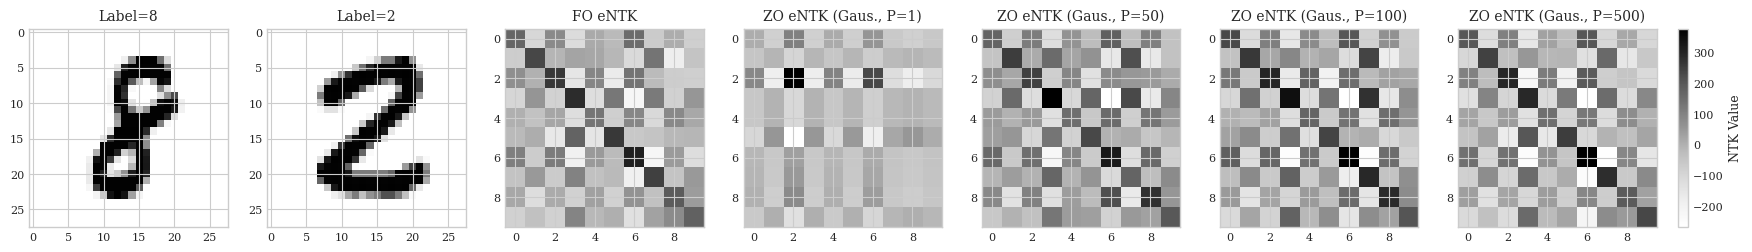

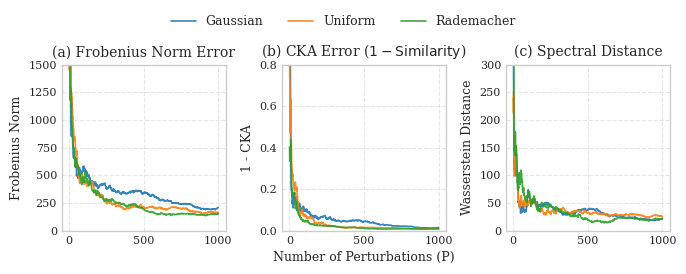

In [26]:
idx1 = 4
idx2 = 10
seed = 42
plot_ntk_p(idx1, idx2, seed=seed, pert=[1, 50, 100, 500])
plot_entk_convergence(idx1=idx1, idx2=idx2, seed=seed)

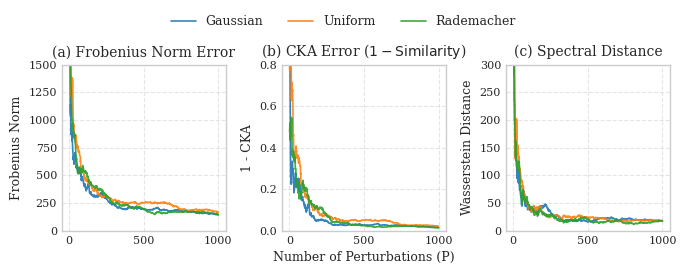

In [27]:
# plot_ntk_p(13, 14, seed=1223, pert=[1, 50, 100, 500])
plot_entk_convergence(idx1=13, idx2=14, seed=1223)